In [2]:
import numpy as np
import matplotlib.pyplot as plt

#import hdf5storage

from datetime               import datetime
from scipy.signal           import hilbert, firwin
from scipy.constants        import pi
from scipy.io               import loadmat

from optic.comm.metrics     import fastBERcalc, calcEVM
from optic.utils            import parameters, dBm2W
from optic.dsp.core         import pnorm, signal_power, upsample, decimate, finddelay, firFilter, clockSamplingInterp
from optic.plot             import pconst

from proc_ofdm              import save_OFDM, tx_OFDM, rx_OFDM, plot_const

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### Parameters initialization

In [4]:
paramOFDM = parameters()

# Modulation parameters
paramOFDM.mode     = "ARoF"
paramOFDM.modOrder = 64                # Modulation order
paramOFDM.modType  = 'qam'             # Modulation type
paramOFDM.numOFDMframes = 10           # Number of ofdm symbols generated

paramOFDM.bw  = 100e6                  # Channel bandwidth
paramOFDM.scs = 30e3                   # Subcarrier spacing

if paramOFDM.bw == 100e6 and paramOFDM.scs == 30e3:
    paramOFDM.Nfft = 2**12

elif paramOFDM.bw == 50e6 and paramOFDM.scs == 30e3:
    paramOFDM.Nfft  = 2**12

elif paramOFDM.bw == 10e6 and paramOFDM.scs == 30e3:
    paramOFDM.Nfft = 2**9

elif paramOFDM.bw == 400e6 and paramOFDM.scs == 480e3:
    paramOFDM.Nfft = 2**11

elif paramOFDM.bw == 100e6 and paramOFDM.scs == 480e3:
    paramOFDM.Nfft = 2**12

elif paramOFDM.bw == 400e6 and paramOFDM.scs == 1e6:
    paramOFDM.Nfft = 2**11

else:
    print("Check parameters for error in Nfft")

paramOFDM.G    = 32                    # Cyclic prefix length
paramOFDM.hermitSymmetry = False       # If true, the OFDM signal respects the Hermitian symmetry
paramOFDM.returnChannel  = False       # If true, the channel estimated response is returned

paramOFDM.saveTx       = False          # If true, the transmitted signal information is saved in a .mat file
paramOFDM.awg_model    = "Tektronix"   # "Keysight" "Tektronix" "R&S"
paramOFDM.awg_filepath = r"C:\Users\PC\Documents\Mestrado\DPD"
paramOFDM.tx_info_path = r"C:\Users\PC\Documents\Mestrado\DPD"
paramOFDM.seed = 3

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

#
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

# RF carrier frequency
paramOFDM.fc = 3.55e9

# Devices sampling frequencies
paramOFDM.Fawg = 25e9
paramOFDM.Fdso = 20e9
paramOFDM.SpS_out = 4  # Samples per symbols after downsampling

sigTx_RF, sigTx_BB, symbTx = tx_OFDM(paramOFDM)

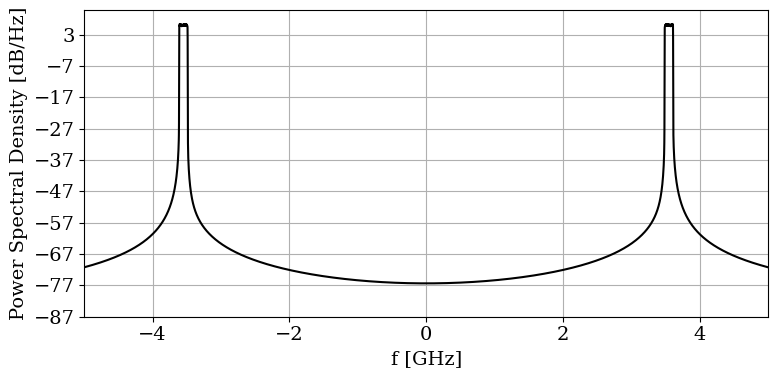

In [5]:
fig, axs = plt.subplots(figsize = (8, 4))
axs.psd(sigTx_RF, Fs = paramOFDM.Fawg/1e9, NFFT = 16*1024, color = "k",sides = 'twosided', label = "sigOFDM-RF")
axs.set_xlabel("f [GHz]")
axs.set_ylabel("Power Spectral Density [dB/Hz]")
axs.set_xlim(-5, 5)
axs.grid(True)
plt.tight_layout()

### Channel with delay and resampling to Fdso sampling rate

In [6]:
filename = r"C:\Users\PC\Documents\Mestrado\DPD\Cooperacao_KTH\Dados_experimentais\att_0dB\dso_data1.mat"
sigRx_exp = loadmat(filename)["dso_data"].ravel()

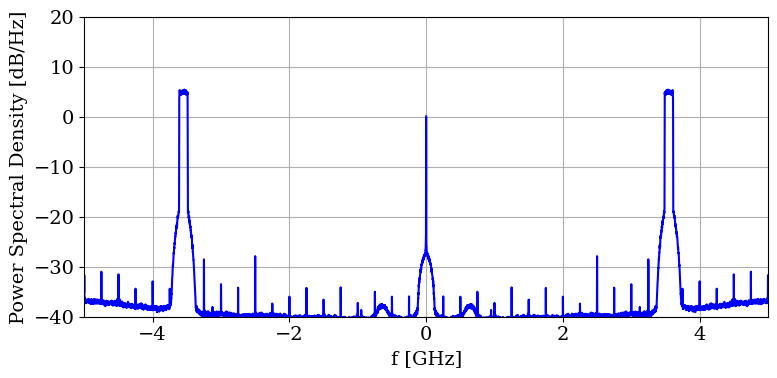

In [7]:
fig, axs = plt.subplots(figsize = (8, 4))
axs.psd(sigRx_exp, Fs = paramOFDM.Fdso/1e9, NFFT = 16*1024, color = "b",sides = 'twosided', label = "sigOFDM-RF")
axs.set_xlabel("f [GHz]")
axs.set_ylabel("Power Spectral Density [dB/Hz]")
axs.set_xlim(-0.5*paramOFDM.Fdso/1e9, 0.5*paramOFDM.Fdso/1e9)
axs.set_xlim(-5, 5)
axs.set_ylim(-40, 20)
axs.set_yticks(np.arange(-40, 21, 10))
axs.grid(True)
plt.tight_layout()

### Demodulation of the received signal

Spectrum after DC level extraction and BP filtering


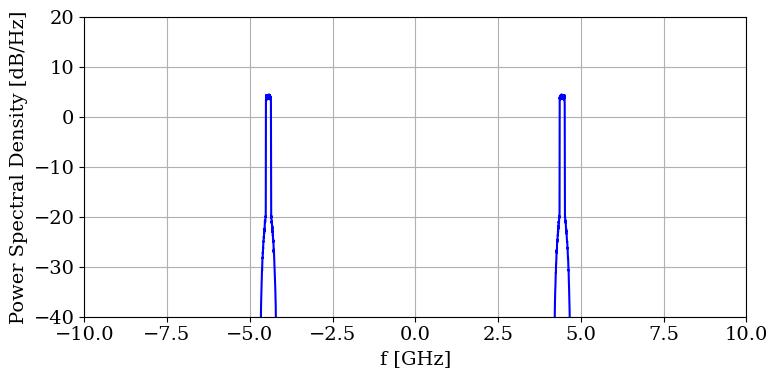

Spectrum after resampling from Fdso to Fawg


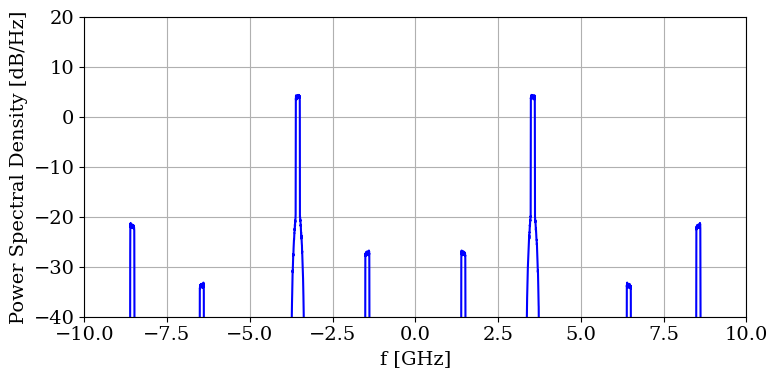

Spectrum after filtering the replicated spectrum from resampling


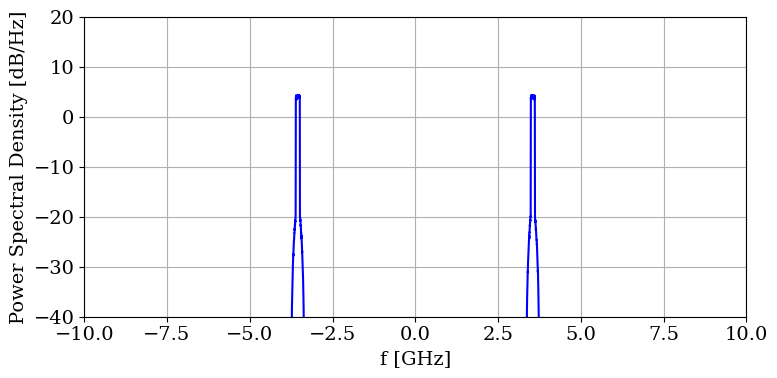

Spectrum after downconversion


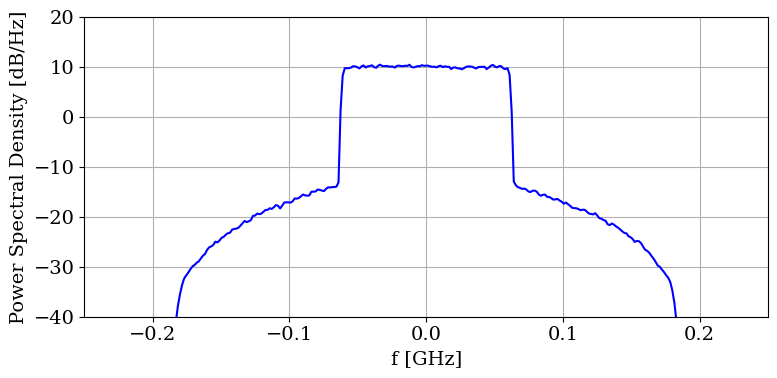

Spectrum after low pass filtering


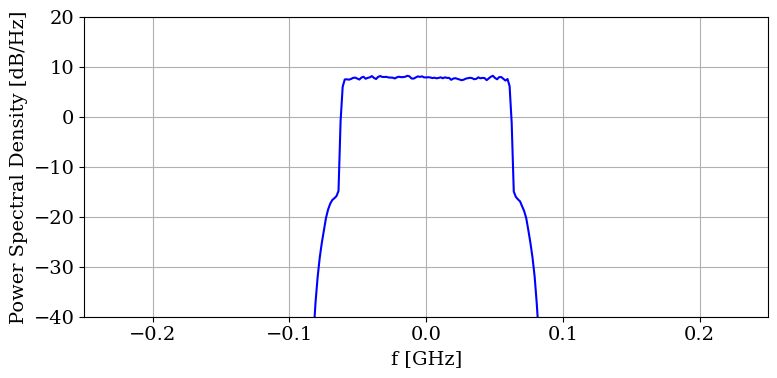

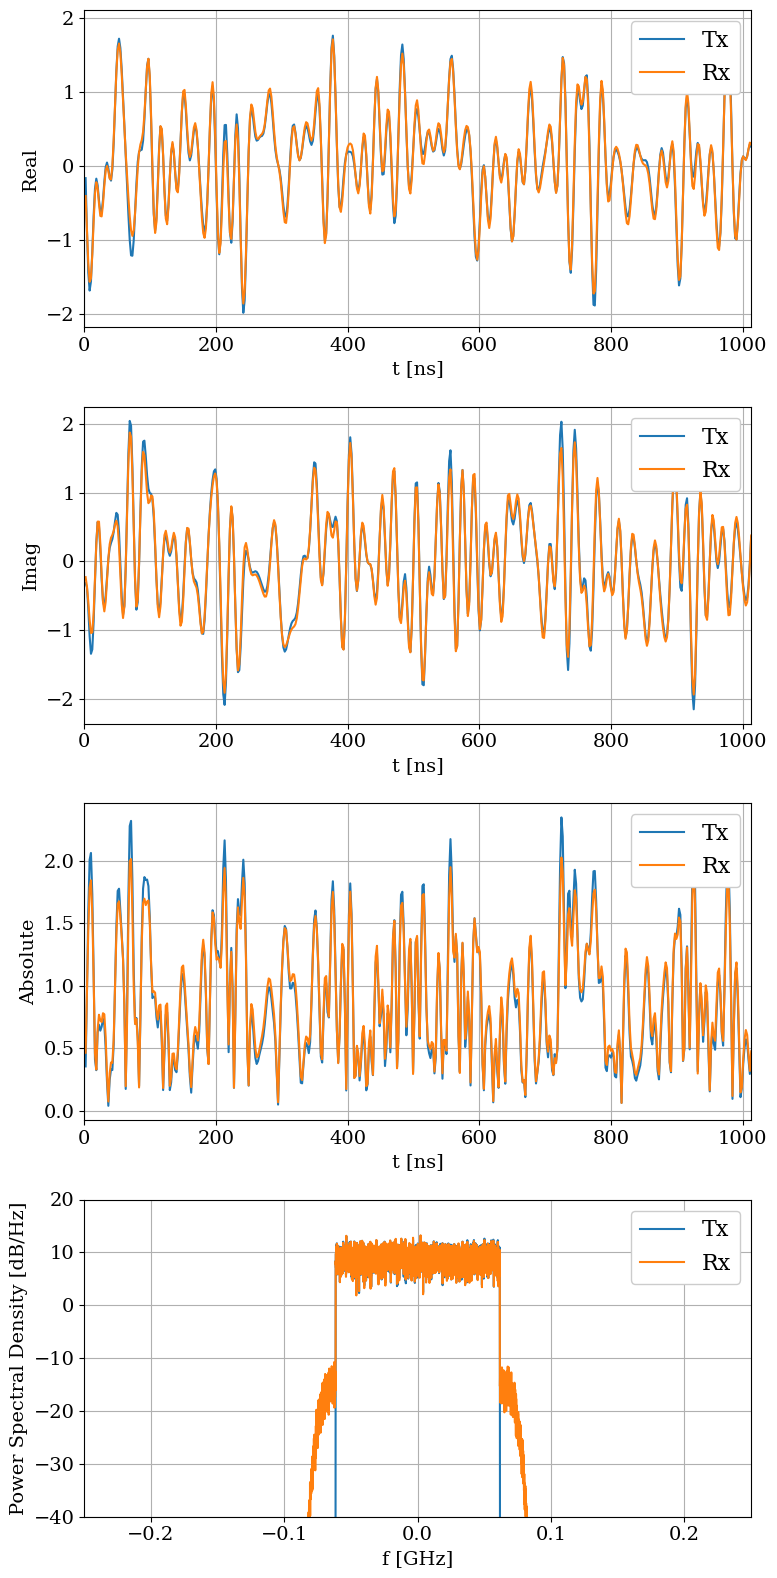

In [8]:
sigRx, sigRx_BB, symbRx = rx_OFDM(sigRx_exp, sigTx_BB, paramOFDM, plot = True)

numOFDMframes_rx = symbRx.size // Ni
samples_per_frame = paramOFDM.SpS*(paramOFDM.Nfft + paramOFDM.G)

BER = 0.0068305524920843855, EVM = 9.53 %


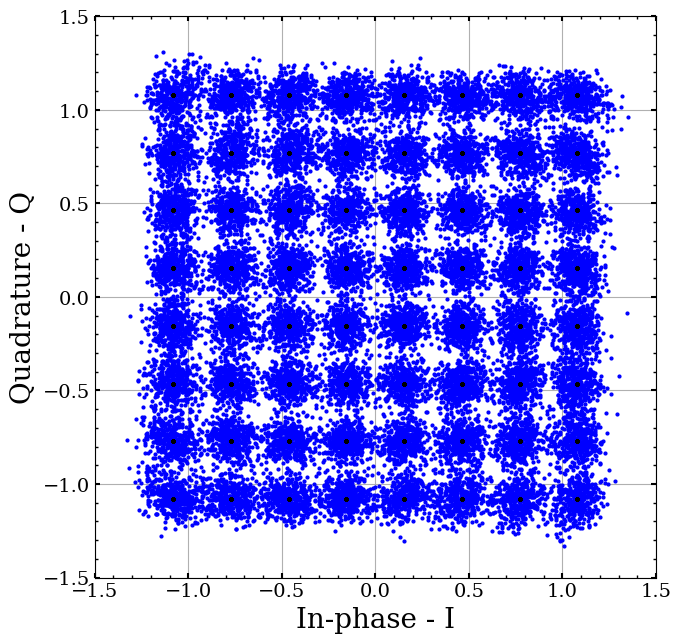

In [10]:
discard = 500
index = np.arange(0, symbRx.size - discard)

BER, _, SNR = fastBERcalc(symbRx[index], symbTx[0:Ni*numOFDMframes_rx][index], paramOFDM.modOrder, paramOFDM.modType)
EVM = np.sqrt(calcEVM(symbRx[index], paramOFDM.modOrder, paramOFDM.modType, symbTx[0:Ni*numOFDMframes_rx][index]))*100

print(f"BER = {BER[0]}, EVM = {EVM[0]:.3} %")

# Normalization for plotting
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

plot_const([symbRx, symbTx], ["b", "k"], index, save = False, show = True)